In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

<h1>#Load Dataset</h1>

The dataset is loaded using Pandas. This dataset contains different mobile phone features such as model name,RAM, processor, battery capacity, 
camera specifications, and price. Understanding this data is essential before building the predictive model.

In [10]:
df = pd.read_csv("Processed_Flipdata_K.csv")



In [11]:
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


<H1>#Data Exploration</H1>

Data exploration helps us understand the structure of the dataset. It shows the number of rows and columns, data types of each feature, summary statistics, and missing values. This step helps identify potential issues in the dataset before preprocessing.

In [12]:
df.shape


(541, 12)

In [13]:
df.dtypes

Unnamed: 0         int64
Model             object
Colour            object
Memory             int64
RAM                int64
Battery_           int64
Rear Camera       object
Front Camera      object
AI Lens            int64
Mobile Height    float64
Processor_        object
Prize             object
dtype: object

In [14]:
df.describe()

,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,289.711645,110.550832,5.397412,4871.587800,0.062847,16.431201
std,182.359185,60.600694,1.984923,780.148862,0.242911,2.523553
min,0.000000,16.000000,2.000000,800.000000,0.000000,4.500000
25%,135.000000,64.000000,4.000000,5000.000000,0.000000,16.510000
50%,273.000000,128.000000,6.000000,5000.000000,0.000000,16.710000
75%,434.000000,128.000000,8.000000,5000.000000,0.000000,16.940000
max,642.000000,256.000000,8.000000,7000.000000,1.000000,41.940000


In [15]:
df.isnull().sum()

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

<h1>#Data Preprocessing:Handle Missing Values</h1>

In [60]:
df.ffill(inplace=True)
df.isnull().sum()

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

Missing values can negatively impact machine learning models. Forward fill replaces missing values with the previous valid value in the column. This ensures the dataset remains complete for model training.

<h1>#Encode Categorical Variables</h1>

In [17]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

Machine learning models require numerical inputs. Since features like model name or processor type are categorical, they must be converted into numerical format using encoding techniques such as Label Encoding.

<h1>#Exploratory Data Analysis</h1>

<h3>Price Distribution Graph</h3>

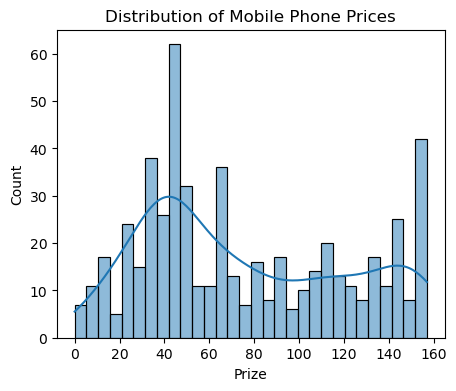

In [69]:
plt.figure(figsize=(5,4))
sns.histplot(df["Prize"], bins=30, kde=True)
plt.title("Distribution of Mobile Phone Prices")
plt.show()

The price distribution graph shows how mobile phone prices are spread across the dataset. It helps identify whether prices are normally distributed or skewed. This insight helps understand pricing trends in the dataset.

<h3>RAM vs Price Graph</h3>

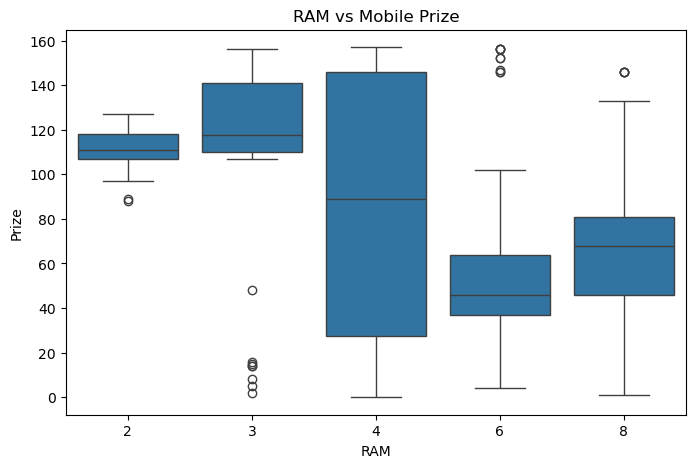

In [53]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["RAM"], y=df["Prize"])
plt.title("RAM vs Mobile Prize")
plt.show()

<h3>Storage vs Price</h3>

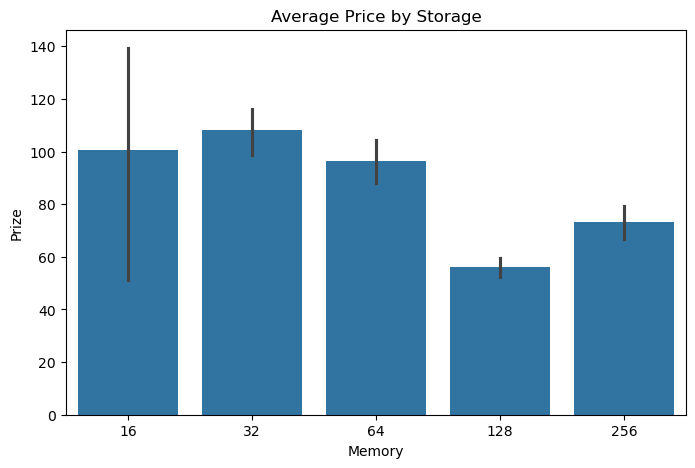

In [54]:
plt.figure(figsize=(8,5))
sns.barplot(x=df["Memory"], y=df["Prize"])
plt.title("Average Price by Storage")
plt.show()

<h3>Battery Capacity vs Price</h3>

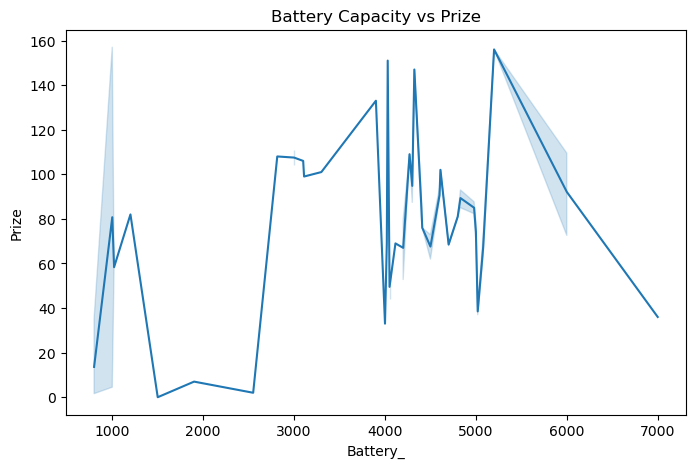

In [55]:
plt.figure(figsize=(8,5))
sns.lineplot(x=df["Battery_"], y=df["Prize"])
plt.title("Battery Capacity vs Prize")
plt.show()

<h3>Processor vs Price</h3>

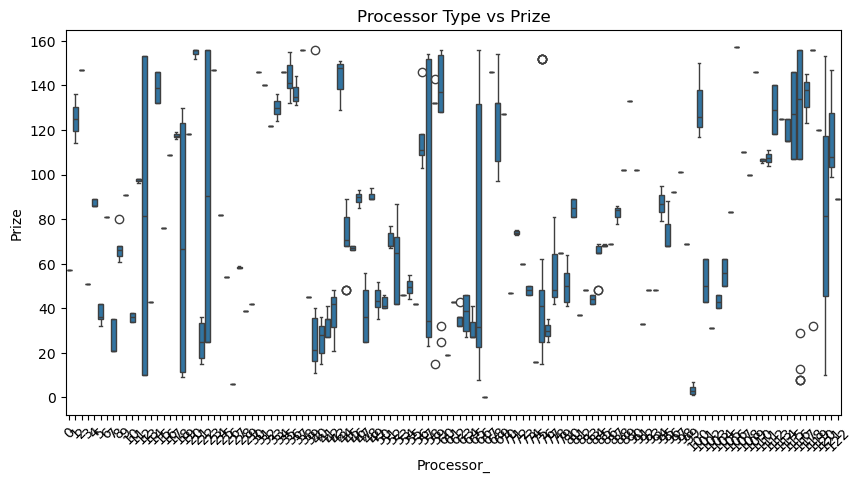

In [56]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["Processor_"], y=df["Prize"])
plt.xticks(rotation=45)
plt.title("Processor Type vs Prize")
plt.show()

<h1>#Correlation Heatmap</h1>

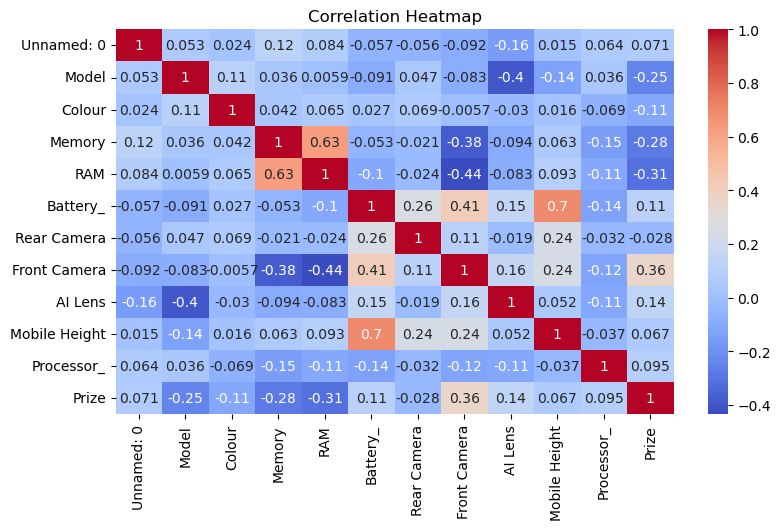

In [64]:
plt.figure(figsize=(9,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

A correlation heatmap displays the relationship between different variables in the dataset. Features with high correlation to price are more important for predicting mobile phone prices. This helps identify key predictors.

<h1>#Feature Extraction</h1>

In [24]:
price_correlation = df.corr()["Prize"].sort_values(ascending=False)
price_correlation

Prize            1.000000
Front Camera     0.359096
AI Lens          0.141326
Battery_         0.111657
Processor_       0.095286
Unnamed: 0       0.070675
Mobile Height    0.066867
Rear Camera     -0.027760
Colour          -0.112165
Model           -0.245361
Memory          -0.282521
RAM             -0.312492
Name: Prize, dtype: float64

Feature extraction helps identify the most important variables affecting mobile phone prices. By analyzing correlation values, we can determine which features such as RAM or processor have the strongest influence on price.

<h1>#Train Test Split</h1>

In [25]:
X = df.drop("Prize", axis=1)
y = df["Prize"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset is divided into training and testing sets. The training data is used to train the machine learning model, while the testing data evaluates how well the model performs on unseen data.

<h1>#Model Building</h1>

<h3>Linear Regression:-</h3>

In [26]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

Linear Regression is a basic machine learning algorithm used for predicting numerical values. It assumes a linear relationship between input features and the target variable. It serves as a baseline model for comparison.

<h3>Decision Tree Regression:-</h3>

In [27]:
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

Decision Tree Regression creates a tree-like structure to split the dataset into smaller groups based on feature values. It captures nonlinear relationships and can model complex interactions between features.

<h3>Random Forest Regression:-</h3>

In [28]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

Random Forest is an ensemble learning algorithm that combines multiple decision trees. It improves prediction accuracy and reduces overfitting by averaging the results of many trees.

<h1>#Model Evaluation</h1>

In [29]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

Model evaluation metrics help measure prediction accuracy. MAE calculates average prediction error, RMSE penalizes larger errors, and R² score indicates how well the model explains the variance in the target variable.

<h1>#Model Comparison Table</h1>

In [31]:
results = pd.DataFrame({
"Model": ["Linear Regression", "Decision Tree", "Random Forest"],

"MAE": [
evaluate_model(y_test, lr_pred)[0],
evaluate_model(y_test, dt_pred)[0],
evaluate_model(y_test, rf_pred)[0]
],

"RMSE": [
evaluate_model(y_test, lr_pred)[1],
evaluate_model(y_test, dt_pred)[1],
evaluate_model(y_test, rf_pred)[1]
],

"R2 Score": [
evaluate_model(y_test, lr_pred)[2],
evaluate_model(y_test, dt_pred)[2],
evaluate_model(y_test, rf_pred)[2]
]

})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,33.480630,39.995894,0.293588
1,Decision Tree,9.009174,23.757568,0.750752
2,Random Forest,12.314037,22.422662,0.777975


The model comparison table helps evaluate which algorithm performs best. By comparing MAE, RMSE, and R² scores, we can determine the most accurate model for predicting mobile phone prices.

<h1>#Feature Importance Graph</h1>

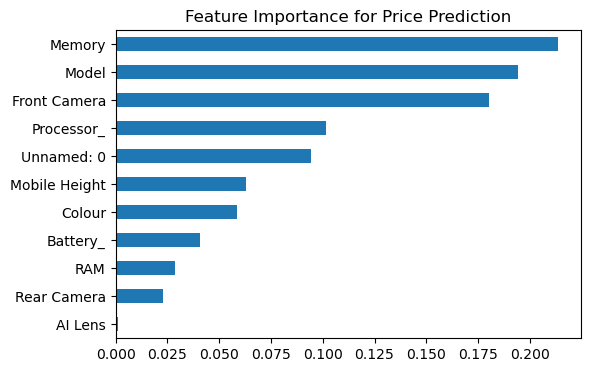

In [67]:
importance = rf_model.feature_importances_
feature_importance = pd.Series(importance, index=X.columns)
feature_importance.sort_values().plot(kind="barh", figsize=(6,4))
plt.title("Feature Importance for Price Prediction")
plt.show()

The feature importance chart highlights which features contribute the most to the model’s predictions. This helps identify the key factors influencing mobile phone prices.